# Comparing the KuaiRand releases: Pure vs 1K vs 27K

Before building models on Pure, check how it was derived from the full release and
what it loses. Documentation says Pure keeps only logs for the 7,583 videos in the
random-exposure candidate pool, and 1K samples 1,000 users with all their logs.

**To run:** download all three releases, then profile each one:

```bash
bash scripts/download_kuairand.sh Pure && bash scripts/download_kuairand.sh 1K && bash scripts/download_kuairand.sh 27K
krec profile --config configs/pure.yaml
krec profile --config configs/1k.yaml
krec profile --config configs/27k.yaml
```

**pool**: the set of candidate videos for random insertion

In [1]:
%matplotlib inline
import os

import pandas as pd

from krec import compare
from krec.config import load_config
from krec.profile import Profile

pd.set_option("display.max_columns", 30)
configs = os.environ.get(
    "KREC_VERSION_CONFIGS", "configs/27k.yaml,configs/pure.yaml,configs/1k.yaml"
).split(",")
root = os.environ.get("KREC_ROOT")
profiles = {}
for path in configs:
    cfg = load_config(path, root=root)
    profiles[cfg.dataset.variant] = Profile.load(cfg)
list(profiles)

['27k', 'pure', '1k']

## 1. Do the raw files match the documented schema?

Per-file checks. Columns which will appear (if there is a problem):
  - `null_or_unparseable_keys`
  - `is_rand_mismatch`
  - `date_time_mismatch`
  - `nonbinary_*`

SQL defined in `src/krec/profile.py`

**Expectation**: No problem columns. Pure's and 1K's files cover the same dates as 27K's.

In [2]:
compare.contracts(profiles)

source      rows  min_date  \
version file                                                                    
27k     log_standard_4_08_to_4_21_27k_part1.csv  standard  68148288  20220408   
        log_standard_4_08_to_4_21_27k_part2.csv  standard  68148288  20220408   
        log_standard_4_22_to_5_08_27k_part1.csv  standard  93062020  20220422   
        log_standard_4_22_to_5_08_27k_part2.csv  standard  92919789  20220422   
        log_random_4_22_to_5_08_27k.csv            random   1186059  20220422   
pure    log_standard_4_08_to_4_21_pure.csv       standard   1141112  20220409   
        log_standard_4_22_to_5_08_pure.csv       standard    295497  20220422   
        log_random_4_22_to_5_08_pure.csv           random   1186059  20220422   
1k      log_standard_4_08_to_4_21_1k.csv         standard   5055984  20220408   
        log_standard_4_22_to_5_08_1k.csv         standard   6657061  20220422   
        log_random_4_22_to_5_08_1k.csv             random     43028  20220422   

                                                 max_date  date_time_mismatch  
version file                                                                   
27k     log_standard_4_08_to_4_21_27k_part1.csv  20220421                 6.0  
        log_standard_4_08_to_4_21_27k_part2.csv  20220421            974544.0  
        log_standard_4_22_to_5_08_27k_part1.csv  20220508              8366.0  
        log_standard_4_22_to_5_08_27k_part2.csv  20220508           1376181.0  
        log_random_4_22_to_5_08_27k.csv          20220508              8627.0  
pure    log_standard_4_08_to_4_21_pure.csv       20220421              9210.0  
        log_standard_4_22_to_5_08_pure.csv       20220508              2716.0  
        log_random_4_22_to_5_08_pure.csv         20220508              8627.0  
1k      log_standard_4_08_to_4_21_1k.csv         20220421             33926.0  
        log_standard_4_22_to_5_08_1k.csv         20220508             48891.0  
        log_random_4_22_to_5_08_1k.csv           20220508               311.0

## 2. Is Pure exactly 27K filtered to the pool?

Matching content with different IDs would mean a release was re-indexed, so joins across
releases by ID couldn't be trusted.

**Expectation**: Pure's random log has the same rows and IDs as 27K's. 1K's doesn't, since it only has its own users' rows.

In [3]:
compare.random_log_identity(profiles)

,random_rows,same_rows_as_27k,same_ids_as_27k
version,,,
27k,1186059,True,True
pure,1186059,True,True
1k,43028,False,False


**Expectation**: Every (day, source) group of 27K's pool rows matches Pure's, so the table below should be empty.

In [4]:
pure_check = compare.pure_vs_full_pool(profiles)
print(
    f"{pure_check.same_rows.sum()} of {len(pure_check)} (day, source) groups identical; "
    f"total row difference {int(pure_check.row_diff.abs().sum()):,}"
)
pure_check[~pure_check.same_rows]

47 of 47 (day, source) groups identical; total row difference 0


,,pure_rows,full_pool_rows,row_diff,same_rows
day,source,,,,


### And is 1K exactly 27K filtered to its users?

1K's construction is inherently different, it takes 1000 sampled users and drops all videos irrelevant to those users.

**Expectation**: User match between 1K and 27K, pool mismatch.

In [5]:
compare.one_k_vs_full(profiles)

,users_in_1k,found_in_27k,users_with_identical_counts
0,1000,1000,1000


In [6]:
compare.pool_coverage(profiles)

,pool_videos,in_27k_pool,not_in_27k_pool,27k_pool_missing
version,,,,
27k,7583,7583,0,0
pure,7583,7583,0,0
1k,7388,7388,0,195


## 3. Is the early decline in standard volume specific to the pool?

Flagged during initial Pure EDA, making sure to pinpoint the source of drops.

**Expectation**: Pure's line lies exactly on 27K's pool line. 27K's non-pool line is roughly flat, apart from a weekly cycle.

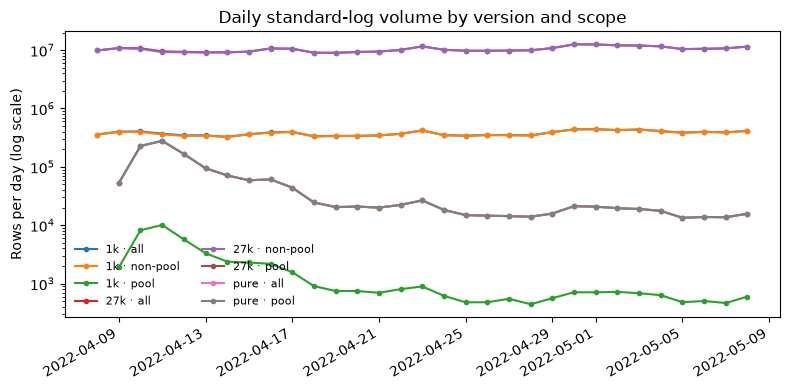

In [7]:
volume = compare.daily_volume_by_scope(profiles)
compare.daily_volume_figure(volume)

In [8]:
compare.daily_volume_table(volume)

version           1k                            27k                        \
scope            all  non-pool     pool         all    non-pool      pool   
day                                                                         
2022-04-08  358009.0  358009.0      NaN   9864349.0   9864349.0       NaN   
2022-04-09  400301.0  398409.0   1892.0  10870341.0  10817605.0   52736.0   
2022-04-10  404561.0  396355.0   8206.0  10749052.0  10521244.0  227808.0   
2022-04-11  370216.0  360130.0  10086.0   9527164.0   9248329.0  278835.0   
2022-04-12  345469.0  339747.0   5722.0   9346113.0   9180037.0  166076.0   
2022-04-13  346408.0  343095.0   3313.0   9189352.0   9094641.0   94711.0   
2022-04-14  326469.0  324096.0   2373.0   9187522.0   9116270.0   71252.0   
2022-04-15  361879.0  359582.0   2297.0   9460878.0   9401986.0   58892.0   
2022-04-16  389039.0  386863.0   2176.0  10703081.0  10642177.0   60904.0   
2022-04-17  396844.0  395274.0   1570.0  10590283.0  10546260.0   44023.0   
2022-04-18  333779.0  332873.0    906.0   9045197.0   9020637.0   24560.0   
2022-04-19  337975.0  337230.0    745.0   8994629.0   8974186.0   20443.0   
2022-04-20  339479.0  338734.0    745.0   9304296.0   9283445.0   20851.0   
2022-04-21  345556.0  344861.0    695.0   9464319.0   9444298.0   20021.0   
2022-04-22  368455.0  367653.0    802.0  10076696.0  10054413.0   22283.0   
2022-04-23  420805.0  419914.0    891.0  11621565.0  11594920.0   26645.0   
2022-04-24  349106.0  348490.0    616.0  10137480.0  10119240.0   18240.0   
2022-04-25  341550.0  341073.0    477.0   9775971.0   9761060.0   14911.0   
2022-04-26  350481.0  350002.0    479.0   9756170.0   9741640.0   14530.0   
2022-04-27  349214.0  348666.0    548.0   9838184.0   9823856.0   14328.0   
2022-04-28  345369.0  344927.0    442.0   9943504.0   9929532.0   13972.0   
2022-04-29  393536.0  392974.0    562.0  10843757.0  10827918.0   15839.0   
2022-04-30  438379.0  437669.0    710.0  12573232.0  12552028.0   21204.0   
2022-05-01  442050.0  441342.0    708.0  12514718.0  12493928.0   20790.0   
2022-05-02  426078.0  425358.0    720.0  12096604.0  12077050.0   19554.0   
2022-05-03  436388.0  435704.0    684.0  11999564.0  11980621.0   18943.0   
2022-05-04  409114.0  408482.0    632.0  11603464.0  11585864.0   17600.0   
2022-05-05  384866.0  384387.0    479.0  10431720.0  10418330.0   13390.0   
2022-05-06  397627.0  397124.0    503.0  10540891.0  10527057.0   13834.0   
2022-05-07  389784.0  389320.0    464.0  10713828.0  10700141.0   13687.0   
2022-05-08  414259.0  413660.0    599.0  11514461.0  11498714.0   15747.0   

version         pure            
scope            all      pool  
day                             
2022-04-08       NaN       NaN  
2022-04-09   52736.0   52736.0  
2022-04-10  227808.0  227808.0  
2022-04-11  278835.0  278835.0  
2022-04-12  166076.0  166076.0  
2022-04-13   94711.0   94711.0  
2022-04-14   71252.0   71252.0  
2022-04-15   58892.0   58892.0  
2022-04-16   60904.0   60904.0  
2022-04-17   44023.0   44023.0  
2022-04-18   24560.0   24560.0  
2022-04-19   20443.0   20443.0  
2022-04-20   20851.0   20851.0  
2022-04-21   20021.0   20021.0  
2022-04-22   22283.0   22283.0  
2022-04-23   26645.0   26645.0  
2022-04-24   18240.0   18240.0  
2022-04-25   14911.0   14911.0  
2022-04-26   14530.0   14530.0  
2022-04-27   14328.0   14328.0  
2022-04-28   13972.0   13972.0  
2022-04-29   15839.0   15839.0  
2022-04-30   21204.0   21204.0  
2022-05-01   20790.0   20790.0  
2022-05-02   19554.0   19554.0  
2022-05-03   18943.0   18943.0  
2022-05-04   17600.0   17600.0  
2022-05-05   13390.0   13390.0  
2022-05-06   13834.0   13834.0  
2022-05-07   13687.0   13687.0  
2022-05-08   15747.0   15747.0

### When were the pool videos uploaded?

If the pool is a set of recently uploaded videos, the decline above is the policy
showing them less as they age.

**Expectation**: A few upload dates around 04-09, the first day pool videos appear in the standard log, with first impressions within a day of upload.

In [9]:
uploads = compare.pool_upload_dates(profiles)
uploads

,videos,never_shown_by_policy,median_days_to_first_standard,standard_rows
upload_date,,,,
2022-04-09,2832,15,0.0,543278
2022-04-10,3424,14,0.0,594325
2022-04-11,1327,3,0.0,299006


## 4. How much of each user's feed survives in Pure?

For every 27K user, the share of their standard impressions on pool videos. A small
share means Pure's user histories are a thin slice of what users actually saw.

**Expectation**: Pool rows are under 0.5% of 27K's standard log (section 3), so most users keep under 1% of their impressions.

In [10]:
compare.pool_share_per_user(profiles)

,users,overall_share,mean_share,p10,p25,p50,p75,p90,users_with_no_pool_rows
27k,27285,0.004458,0.004933,0.001661,0.002795,0.004507,0.006597,0.008727,208


## 5. How do pool videos differ from what the policy shows?

The random log only covers pool videos, so this describes what the unbiased eval set
is made of, compared with standard-log traffic.

7s and 18s are the thresholds KuaiRand uses for a
valid play and a long view.

**Expectation**: Click and long-view rates are lowest for 0–7s videos, since both labels depend on watch time.

In [11]:
compare.pool_typicality(profiles, 'duration')

,non_pool_share,pool_share,non_pool_click_rate,pool_click_rate,non_pool_long_view_rate,pool_long_view_rate
bucket,,,,,,
0-7s,0.134459,0.034403,0.303554,0.329981,0.201934,0.246742
7-18s,0.277402,0.143079,0.379151,0.404704,0.277928,0.281511
18-60s,0.222887,0.261378,0.377879,0.478391,0.242896,0.347150
1-3min,0.250600,0.389100,0.408185,0.483502,0.284013,0.355957
3min+,0.114652,0.172041,0.399880,0.448876,0.266605,0.312909


**Expectation**: Pool videos are all 0–29 days old when shown, since they were uploaded 04-09..04-11 and the logs end 05-08. Non-pool videos span every age.

In [12]:
compare.pool_typicality(profiles, 'age_at_impression')

,non_pool_share,pool_share,non_pool_click_rate,pool_click_rate,non_pool_long_view_rate,pool_long_view_rate
bucket,,,,,,
0d,0.206184,0.128473,0.348548,0.439639,0.234699,0.323106
1-7d,0.492564,0.600391,0.386463,0.469457,0.264671,0.340701
8-30d,0.127015,0.271136,0.404513,0.447428,0.278719,0.316356
31-180d,0.174178,NaN,0.371690,NaN,0.263877,NaN
181-365d,0.000037,NaN,0.157882,NaN,0.067283,NaN
365d+,0.000005,NaN,0.168033,NaN,0.036885,NaN
unknown,0.000017,NaN,0.389376,NaN,0.233662,NaN


In [13]:
compare.pool_typicality(profiles, 'upload_type')

,non_pool_share,pool_share,non_pool_click_rate,pool_click_rate,non_pool_long_view_rate,pool_long_view_rate
bucket,,,,,,
ALBUM2020,1.870081e-08,NaN,0.333333,NaN,0.166667,NaN
ALBUM2021,1.708007e-06,NaN,0.257299,NaN,0.147810,NaN
AiCutVideo,1.605355e-03,0.000014,0.252659,0.300000,0.184111,0.200000
CommonAvatar,3.740161e-07,NaN,0.108333,NaN,0.075000,NaN
CommonBackground,7.792003e-08,NaN,0.040000,NaN,0.040000,NaN
CommonMilepost,3.116801e-09,NaN,0.000000,NaN,0.000000,NaN
Copy,7.480323e-08,NaN,0.458333,NaN,0.291667,NaN
FlashPhoto,1.030570e-03,NaN,0.259211,NaN,0.180236,NaN
FollowShoot,2.577136e-03,0.000112,0.245021,0.167702,0.151861,0.105590


### Label rates and exposure concentration

**Expectation**: Pure's rates equal 27K's pool rates, and 1K's are within sampling noise of 27K's. Random rates are lower than standard policy.

In [14]:
compare.label_rates(profiles)

rows  click_rate  long_view_rate
version source   in_pool                                       
27k     random   True       1186059    0.176158        0.084961
        standard False    320841776    0.378355        0.260128
                 True       1436609    0.459653        0.331840
pure    random   True       1186059    0.176158        0.084961
        standard True       1436609    0.459653        0.331840
1k      random   True         43028    0.174119        0.084155
        standard False     11662003    0.377829        0.261729
                 True         51042    0.462306        0.336507

**Expectation**: The random log is close to uniform (Gini near 0) and the standard log is concentrated.

In [15]:
compare.concentration(profiles)

items_shown  impressions      gini  top_1pct_share
version source   in_pool                                                    
27k     random   True            7583    1186059.0  0.080809        0.012537
        standard False       32031142  320841776.0  0.826521        0.440434
                 True            7551    1436609.0  0.711693        0.173496
pure    random   True            7583    1186059.0  0.080809        0.012537
        standard True            7551    1436609.0  0.711693        0.173496
1k      random   True            7388      43028.0  0.234785        0.022660
        standard False        4364480   11662003.0  0.539715        0.173522
                 True            5473      51042.0  0.639884        0.146761

In [16]:
compare.tab_mix(profiles)

share                                        click_rate  \
group random · pool standard · non-pool standard · pool random · pool   
tab                                                                     
0               NaN            0.198683        0.123963           NaN   
1          0.993226            0.669697        0.736727      0.177286   
2          0.000644            0.030860        0.033665      0.113874   
3               NaN            0.002972        0.002794           NaN   
4               NaN            0.076104        0.064851           NaN   
5               NaN            0.001325        0.002902           NaN   
6               NaN            0.016287        0.029782           NaN   
7               NaN            0.000356        0.000351           NaN   
8               NaN            0.001478        0.002721           NaN   
9               NaN            0.000188        0.000309           NaN   
10              NaN            0.000073        0.000106           NaN   
11         0.005695            0.000676        0.000505      0.000000   
12              NaN            0.001030        0.001025           NaN   
13              NaN            0.000224        0.000278           NaN   
14         0.000434            0.000047        0.000022      0.000000   

                                           
group standard · non-pool standard · pool  
tab                                        
0                0.116052        0.090838  
1                0.443251        0.523007  
2                0.423941        0.480068  
3                0.021134        0.022422  
4                0.544206        0.615499  
5                0.236105        0.277764  
6                0.177738        0.175669  
7                0.441559        0.402778  
8                0.040477        0.040931  
9                0.992330        0.993243  
10               0.999661        1.000000  
11               0.000594        0.000000  
12               0.122306        0.135870  
13               0.363140        0.348371  
14               0.000267        0.000000

## 6. Is 1K a fair sample of 27K's users?

**Expectation**: 1K's users resemble 27K's on activity and profile.

In [17]:
compare.user_sample(profiles)

,27k,1k
users,27285.000000,1000.000
median_standard_rows,8594.000000,8327.500
p90_standard_rows,24587.400000,24418.500
median_register_days,1188.000000,1234.000
share_video_authors,0.816419,0.808
active_2_14_day_new,0.023273,0.023
active_30day_retention,0.000550,0.002
active_UNKNOWN,0.000220,NaN
active_day_new,0.000403,NaN
active_full_active,0.658200,0.640


## 7. Do `date` and `time_ms` agree?

The first notebook found rows whose `date` differs from the date of `time_ms` in Beijing
time. Before choosing which clock to split and order by, look at the shape of the
disagreement.

**Expectation**: If `date` and `time_ms` were stamped at slightly different moments, they disagree by exactly one day and only near midnight.

In [18]:
compare.clock_summary(profiles)

rows  mismatched  \
version file                                                            
27k     log_random_4_22_to_5_08_27k.csv           1186059        8627   
        log_standard_4_08_to_4_21_27k_part1.csv  68148288           6   
        log_standard_4_08_to_4_21_27k_part2.csv  68148288      974544   
        log_standard_4_22_to_5_08_27k_part1.csv  93062020        8366   
        log_standard_4_22_to_5_08_27k_part2.csv  92919789     1376181   
pure    log_random_4_22_to_5_08_pure.csv          1186059        8627   
        log_standard_4_08_to_4_21_pure.csv        1141112        9210   
        log_standard_4_22_to_5_08_pure.csv         295497        2716   
1k      log_random_4_22_to_5_08_1k.csv              43028         311   
        log_standard_4_08_to_4_21_1k.csv          5055984       33926   
        log_standard_4_22_to_5_08_1k.csv          6657061       48891   

                                                 mismatch_share  \
version file                                                      
27k     log_random_4_22_to_5_08_27k.csv            7.273669e-03   
        log_standard_4_08_to_4_21_27k_part1.csv    8.804330e-08   
        log_standard_4_08_to_4_21_27k_part2.csv    1.430034e-02   
        log_standard_4_22_to_5_08_27k_part1.csv    8.989704e-05   
        log_standard_4_22_to_5_08_27k_part2.csv    1.481042e-02   
pure    log_random_4_22_to_5_08_pure.csv           7.273669e-03   
        log_standard_4_08_to_4_21_pure.csv         8.071075e-03   
        log_standard_4_22_to_5_08_pure.csv         9.191295e-03   
1k      log_random_4_22_to_5_08_1k.csv             7.227852e-03   
        log_standard_4_08_to_4_21_1k.csv           6.710069e-03   
        log_standard_4_22_to_5_08_1k.csv           7.344232e-03   

                                                 hourmin_hour_matches_overall  \
version file                                                                    
27k     log_random_4_22_to_5_08_27k.csv                              0.830680   
        log_standard_4_08_to_4_21_27k_part1.csv                      0.781170   
        log_standard_4_08_to_4_21_27k_part2.csv                      0.862926   
        log_standard_4_22_to_5_08_27k_part1.csv                      0.782097   
        log_standard_4_22_to_5_08_27k_part2.csv                      0.871130   
pure    log_random_4_22_to_5_08_pure.csv                             0.830680   
        log_standard_4_08_to_4_21_pure.csv                           0.822804   
        log_standard_4_22_to_5_08_pure.csv                           0.823853   
1k      log_random_4_22_to_5_08_1k.csv                               0.830297   
        log_standard_4_08_to_4_21_1k.csv                             0.821922   
        log_standard_4_22_to_5_08_1k.csv                             0.827464   

                                                 offset_+1  \
version file                                                 
27k     log_random_4_22_to_5_08_27k.csv                1.0   
        log_standard_4_08_to_4_21_27k_part1.csv        1.0   
        log_standard_4_08_to_4_21_27k_part2.csv        1.0   
        log_standard_4_22_to_5_08_27k_part1.csv        1.0   
        log_standard_4_22_to_5_08_27k_part2.csv        1.0   
pure    log_random_4_22_to_5_08_pure.csv               1.0   
        log_standard_4_08_to_4_21_pure.csv             1.0   
        log_standard_4_22_to_5_08_pure.csv             1.0   
1k      log_random_4_22_to_5_08_1k.csv                 1.0   
        log_standard_4_08_to_4_21_1k.csv               1.0   
        log_standard_4_22_to_5_08_1k.csv               1.0   

                                                 hourmin_hour_matches_time_ms  \
version file                                                                    
27k     log_random_4_22_to_5_08_27k.csv                                   0.0   
        log_standard_4_08_to_4_21_27k_part1.csv                           0.0   
        log_standard_4_08_to_4_21_27k_part2.cs

**Expectation**: Mismatches only in the last hours before midnight, none the rest of the day.

In [19]:
compare.clock_by_hour(profiles)

file,log_random_4_22_to_5_08_27k.csv,log_standard_4_08_to_4_21_27k_part1.csv,log_standard_4_08_to_4_21_27k_part2.csv,log_standard_4_22_to_5_08_27k_part1.csv,log_standard_4_22_to_5_08_27k_part2.csv
ts_hour,,,,,
0,0.000000,0.000000,0.000000,0.000000e+00,0.000000
1,0.000000,0.000000,0.000000,0.000000e+00,0.000000
2,0.000000,0.000000,0.000000,0.000000e+00,0.000000
3,0.000000,0.000000,0.000000,0.000000e+00,0.000000
4,0.000000,0.000000,0.000000,0.000000e+00,0.000000
5,0.000000,0.000000,0.000000,0.000000e+00,0.000000
6,0.000000,NaN,0.000000,NaN,0.000000
7,0.000000,0.000000,0.000000,0.000000e+00,0.000000
8,0.000000,0.000000,0.000000,0.000000e+00,0.000000


**Expectation**: Parts of one export are split arbitrarily, so they share users and mismatch at similar rates.

In [20]:
compare.part_files(profiles)

,users,min_user_id,max_user_id,users_also_in_sibling,users_with_mismatches,mismatch_rate_among_those_users
file,,,,,,
log_standard_4_08_to_4_21_27k_part1.csv,26858,0,27284,26811.0,4,0.000809
log_standard_4_08_to_4_21_27k_part2.csv,26857,0,27284,26811.0,16290,0.020377
log_standard_4_22_to_5_08_27k_part1.csv,27285,0,27284,27285.0,1424,0.001168
log_standard_4_22_to_5_08_27k_part2.csv,27285,0,27284,27285.0,18269,0.020043
log_random_4_22_to_5_08_27k.csv,27285,0,27284,NaN,4365,0.022252


## Findings

1. **Schema.** 
   Schema is consistent with what is advertised in the documentation.
   Only inconsistency is some `date` vs `time_ms` mismatch.
   
   *Consequence:* Splits rely on `date`, the documented day field.
2. **Construction.** 
   Dataset construction is consistent with documentation. 
   
   *Consequence:* IDs are shared across releases, so
   models can train on 1K or 27K logs and be evaluated on the same random log.
3. **The pool is extracted from just 3 days of uploads** 
   All 7,583 pool videos were uploaded on
   04-09 (2,832), 04-10 (3,424), or 04-11 (1,327).
   
   *Consequence:* Item statistics for pool videos, like popularity, are degraded
   over time.
4. **User histories.** Pure keeps a median 0.45% of each user's standard
   impressions (p90 0.87%); 208 users have none. 
   
   *Consequence:* Pure can't support
   history-based or sequential user models.
5. **The eval pool is a specific slice of videos.** By standard-log impressions,
   pool videos are longer than non-pool ones (1–3min: 39% vs 25%; 0–7s: 3.4% vs
   13.4%).
   Their click and long-view rates are higher in every duration and age bucket and in
   the upload types that make up most impressions. 
   
   *Consequence:* Both labels depend on
   watch time, so duration belongs in the models as a feature.
6. **1K is a fair sample of 27K's users.** It matches 27K on activity, account age
   and active degree, and its label rates are within 0.003 of 27K's. Its random-log
   Gini (0.23 vs 27K's 0.08) is what sampling noise alone predicts at about 6
   impressions per video.
   
   *Consequence:* 1K can stand in for 27K
   during development, but its own random log (43K rows) is too small for headline
   numbers.
7. **Clocks.** About 0.7% of rows have a `date` one day after the Beijing date of
   `time_ms`: never the other way, never by more than a day, and only for `time_ms`
   between 21:00 and 23:59.
   
   *Consequence:* `ingest` and the table loaders order events by (`date`, `time_ms`),
   so event order never contradicts a split made on `date`.
8. **Calendar.** 27K's volume is high 04-30..05-04 and dips on 04-24 and 05-07,
   matching China's 2022 Labor Day holiday and its make-up working days. Val
   (05-01..05-04) is holiday traffic; test (05-05..05-08) is not. 
   
   *Consequence:*
   Before using val to choose models or hyperparameters, check that models rank the
   same way on val and test.